# Oregon Surf Analysis
+ Xander Hawkins  
+ Spring 2026

## Project Overview
This project seeks to understand the regional differences in surfing conditions in Oregon.  

Using historical data from the National Data Buoy Center's offshore buoy stations, various conditions such as
Ocean temperature, swell, wave height and period and direction are used to determine whether the South,
Central, or North Coast of Oregon have experienced the best, most consistent surfing conditions. Conventional
wisdom in Oregon claims that the Central Coast is best, and I seek to rigorously test that hypothesis against the data.

Some NDBC Buoys (including those selected for this project) have additional spectral data available on wave behavior.
With the use of Fourier Analysis, this allows us to differentiate between waves caused by swell and those by wind, 
which has tremendous implications for surfing. However, the spectral data substantially increases the volume of data
for cleaning, and the analyis required is non-trivial. Therefore, it remains a stretch goal for this project.

While I initially sought to determine which beach is best, the buoy data is not granular enough. There are a few
interesting approaches to approximating historical conditions at the level of individual beaches, but for now a
regional analysis was more practical given time constraints.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from ndbc_api import NdbcApi

## Configuration
Here, the data parameters can be easily modified to adjust the scope of the analysis. A few key marks:
+ Regional coverage: add or remove buoys. Buoy IDs and locations can be found online.
+ Temporal coverage: reduce or increase start & end date. Note that many buoys have limited historical data.
+ Sentinel values: adjust these if NDBC changes their structure in the future.

In [2]:
# Configuration 

# NDBC buoy stations, grouped by Oregon coast region
BUOYS = {
    'north':   '46089',  # Tillamook, 85 NM WNW of Tillamook
    'central': '46050',  # Stonewall Bank, 20 NM W of Newport
    'south':   '46015',  # Port Orford, 15 NM W of Port Orford
}

# Analysis time window: inclusive on both ends. NDBC API expects 'yyyy-mm-dd'
START_DATE = '2015-01-01'
END_DATE = '2025-12-31'

# NDBC sentinel values for missing data across their various fields
NDBC_MISSING = [99.0, 999.0, 9999.0]

# Output paths
DATA_DIR = 'data'
CACHE_DIR = 'data/raw'

## Data Import
### Standard Meteorological Data
Import the standard data from each of the specified buoys for the given time period.

As of April 2026, the NDBC API function for pulling buoy data has a bug. Therefore, we define a custom function for
pulling one buoy-year of data using the buoy station number and the year. Then, we loop through our regions and years
and concatenate the buoy-years of data into a single dataframe. 

If any years are missing, they will be skipped rather than shutting down the import. Missing years will be dealt
with in a later section during data cleaning. As of April 2026, it is a known issue that one of the selected buoys
is missing a year: South Coast, 2023.

In [3]:
# ============================================================
# Fetch stdmet data for all buoys and combine into one DataFrame
# ============================================================
api = NdbcApi()
def fetch_ndbc_year(station, year):
    """Fetch one year of stdmet data for one NDBC station."""
    url = (f"https://www.ndbc.noaa.gov/view_text_file.php"
           f"?filename={station}h{year}.txt.gz"
           f"&dir=data/historical/stdmet/")
    # Row 0: column names (starts with '#'). Row 1: units (also '#'). Skip units.
    df = pd.read_csv(
        url, sep=r'\s+', header=0, skiprows=[1],
        na_values=NDBC_MISSING
    )
    df.columns = df.columns.str.lstrip('#')
    # Build datetime index from the separate date-part columns
    df['time'] = pd.to_datetime(
        df[['YY', 'MM', 'DD', 'hh', 'mm']].rename(
            columns={'YY':'year', 'MM':'month', 'DD':'day',
                     'hh':'hour', 'mm':'minute'}
        )
    )
    return df.set_index('time').drop(columns=['YY', 'MM', 'DD', 'hh', 'mm'])


frames = []
for region, station in BUOYS.items():
    print(f"Fetching {region} coast (station {station})...")
    station_frames = []
    for year in range(int(START_DATE[:4]), int(END_DATE[:4]) + 1):
        try:
            df_year = fetch_ndbc_year(station, year)
            station_frames.append(df_year)
        except Exception as e:
            print(f"  skipped {year}: {e}")
    df = pd.concat(station_frames, axis=0)
    df['station'] = station
    df['region'] = region
    frames.append(df)
    print(f"  → {len(df):,} rows")

stdmet = pd.concat(frames, axis=0).sort_index()
print(f"\nCombined dataset: {len(stdmet):,} rows across "
      f"{stdmet['region'].nunique()} regions")
stdmet.head()
stdmet.info()


Fetching north coast (station 46089)...
  → 230,981 rows
Fetching central coast (station 46050)...
  → 464,058 rows
Fetching south coast (station 46015)...
  skipped 2023: HTTP Error 404: Not Found
  → 233,399 rows

Combined dataset: 928,438 rows across 3 regions
<class 'pandas.DataFrame'>
DatetimeIndex: 928438 entries, 2014-12-31 23:50:00 to 2025-12-31 23:50:00
Data columns (total 15 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   WDIR     888103 non-null  float64
 1   WSPD     914513 non-null  float64
 2   GST      914158 non-null  float64
 3   WVHT     275310 non-null  float64
 4   DPD      274614 non-null  float64
 5   APD      275310 non-null  float64
 6   MWD      272722 non-null  float64
 7   PRES     927308 non-null  float64
 8   ATMP     590441 non-null  float64
 9   WTMP     806319 non-null  float64
 10  DEWP     297814 non-null  float64
 11  VIS      0 non-null       float64
 12  TIDE     0 non-null       float64
 13  station  928

## Data Cleaning
### Selecting Columns for Analysis

**NOTE**: If you accidentally or unintentionally alter the dataframe later in analysis, restart from HERE to avoid re-importing the data from NDBC. In the following code cell, we assign the cleaned version of the dataframe to a new variable, protecting the original from mishaps.

Not every variable is important for our data analysis. Meanwhile, some have limited entries that could be caused by sensor outages.
See below for a schema table explaining the columns pulled from NDBS Buoys. Then, we overview which variables are important for surfing analysis.

#### Variable Reference

| Column | Stands For | Description |
|--------|-----------|-------------|
| WDIR | Wind Direction | Direction (degrees clockwise from true north) the wind is coming from, averaged over an 8-minute sampling window. |
| WSPD | Wind Speed | Wind speed in meters per second, averaged over the same 8-minute window. |
| GST | Gust Speed | Peak wind gust in meters per second observed during the sampling window. |
| WVHT | Wave Height (significant) | Significant wave height in meters, defined as the average height of the largest one-third of waves in the 20-minute wave-sampling window. |
| DPD | Dominant Period | Wave period in seconds corresponding to the peak of the wave energy spectrum — the single most important variable distinguishing groundswell from wind sea. |
| APD | Average Period | Mean wave period in seconds across all frequencies in the spectrum; always less than or equal to DPD. |
| MWD | Mean Wave Direction | Direction (degrees clockwise from true north) that the dominant-period waves are coming from. |
| PRES | (Barometric) Pressure | Sea-level atmospheric pressure in hectopascals (hPa); a proxy for storm activity. |
| ATMP | Air Temperature | Air temperature in degrees Celsius, measured a few meters above the sea surface. |
| WTMP | Water Temperature | Sea surface temperature in degrees Celsius, measured ~1–2 meters below the waterline. |
| DEWP | Dewpoint Temperature | Temperature in degrees Celsius at which the ambient air would become saturated, indicating humidity and fog potential. |
| VIS | Visibility | Horizontal visibility in nautical miles; not measured by the offshore buoys in this dataset. |
| TIDE | Tide Height | Local tide height in feet; not measured by offshore buoys (tides are recorded at coastal tide gauges instead). |

#### Relevant Data Points
To analyze surf conditions based on the standard meteorological data, we need to consider the following:  
+ **Wave state: Wave Height (WVHT), Dominant Period (DPD), Mean Wave Direction (MWD).**
    - We drop Average Period (APD). There are almost always overlapping periods, but the dominant one is most relevant to surfing. For a detailed analysis of wave behavior, advanced spectral data is required. There simply isn't enough information in stdmet, even with APD.
+ **Wind state: Wind Speed (WSPD), Wind Direction (WDIR).**
    - For this analysis, Gust Speed (GST) was not considered important enough for surfing analysis.
+ **Comfort: Water Temperature (WTMP).**
    - For this analysis, Air Temperature (ATMP) was not considered important enough for surfing analysis.  

Other dropped columns include:
+ Atmospheric data: Barometric pressure (PRES), Dewpoint temperature (DEWP) not relevant to analysis.
+ Unmeasured data: Tide Height (TIDE), Visibility (VIS) not tracked by offshore buoys.

In the following code cell, we drop the selected irrelevant columns before beginning cleaning.

In [4]:
# ============================================================
# Drop irrelevant columns from the dataframe, store safely.
# ============================================================

# Define the columns we will drop
columns_to_drop = [
    'APD',      # Average Period
    'GST',      # Wind Gusts
    'ATMP',     # Air Temperature
    'VIS',      # Visibility
    'TIDE',     # Tide Height
    'PRES',     # Barometric pressure
    'DEWP',     # Dewpoint temperature
]

# Place the cleaned dataframe into a new variable.
# Pulling the data from NDBC takes awhile. By altering the dataframe in a
# separate variable, we reduce the risk of needing to re-import data due to
# a mistake. Instead, we simply restart from this cell.
cleaned_stdmet = stdmet.drop(columns=columns_to_drop)
# Verify that the expected columns remain.
cleaned_stdmet.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 928438 entries, 2014-12-31 23:50:00 to 2025-12-31 23:50:00
Data columns (total 8 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   WDIR     888103 non-null  float64
 1   WSPD     914513 non-null  float64
 2   WVHT     275310 non-null  float64
 3   DPD      274614 non-null  float64
 4   MWD      272722 non-null  float64
 5   WTMP     806319 non-null  float64
 6   station  928438 non-null  str    
 7   region   928438 non-null  str    
dtypes: float64(6), str(2)
memory usage: 63.8 MB


### Examining Regional Completeness

Unfortunately, the buoys experience sensor outages. As a result, full wave data are less numerous than wind and temperature data. However, dropping all rows that are missing *any* data risks significant bias toward favorable conditions, which could meaningfully affect the analysis.

Before deciding which columns to drop, we analyze the completeness of the data across regions.

In [5]:
# ============================================================
# Per-region, per-variable completeness assessment
# ============================================================
# Before dropping any rows, examine how complete each variable is within
# each region. Listwise deletion would be inappropriate if completeness
# varies systematically by region, since it would cause some regions to
# be under-represented in the regional comparison.

# Perform the calculation, and present as XX.X % percentages
completeness = (
    cleaned_stdmet
    .groupby('region')
    .apply(lambda g: g.drop(columns=['station',]).notna().sum() / len(g))
    .mul(100)
    .round(1)
)

# Reorder regions geographically (N to S) rather than alphabetically
completeness = completeness.reindex(['north', 'central', 'south'])

# Add a row showing each region's total observation count for context
row_counts = cleaned_stdmet.groupby('region').size().reindex(['north', 'central', 'south'])
print("Observations per region:")
print(row_counts.to_string())
print(f"\nPercent non-null by variable and region:")
completeness

Observations per region:
region
north      230981
central    464058
south      233399

Percent non-null by variable and region:


,WDIR,WSPD,WVHT,DPD,MWD,WTMP
region,,,,,,
north,94.8,96.9,40.8,40.8,40.8,94.1
central,98.4,99.0,25.0,24.8,24.5,79.2
south,91.1,99.0,27.9,27.9,27.8,94.9


#### A Closer Look at Wave Data Completeness
If you have selected different buoys or dates, you may find something different than I, and this would be a good time to reconsider which rows you keep for your analysis. From my review of the data completeness, we have a few interesting findings:
+ **Wind data is highly consistent**, with over 90% completeness across regions.
+ **Water temperature has a minor anomaly**, where the central region has about 3/4ths the data of the other two.
+ **Wave data varies significantly.** North, Central and South have 40%, 25%, and 28% completeness respectively. 

Since the wave data appears regionally variant, we examine the completeness over time. If large chunks are missing, these indicate specific, infrequent outages occurred. If the missing data is spread more evenly over time, then it is more likely that the buoy itself is less reliable--either due to mechanical issues, or more frequent disruptive conditions. It will be easier to work around large chunks. 
Finally (as I found with my data), it's possible that frequency of recordings was simply changed--which would be indicated by sharp drops
to specific fractional levels.

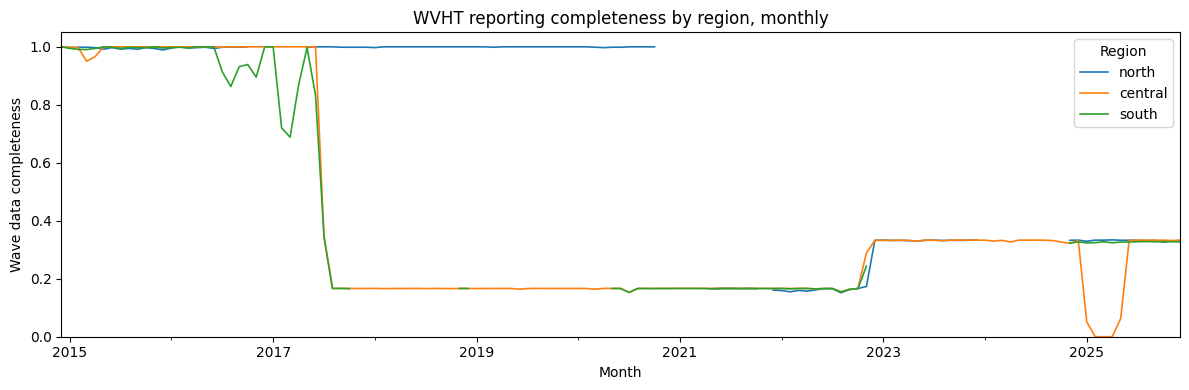

In [6]:
# ============================================================
# Monthly completeness timeline for wave measurements
# ============================================================
# Visualize whether wave-data gaps are concentrated in specific time periods
# (indicating outages) or spread uniformly (indicating chronic sensor issues).

monthly_wave_completeness = (
    cleaned_stdmet
    .assign(has_wave=cleaned_stdmet['WVHT'].notna())
    .groupby(['region', pd.Grouper(freq='ME')])['has_wave']
    .mean()
    .unstack('region')
    .reindex(columns=['north', 'central', 'south'])
)

fig, ax = plt.subplots(figsize=(12, 4))
monthly_wave_completeness.plot(ax=ax, linewidth=1.2)
ax.set_ylabel('Wave data completeness')
ax.set_xlabel('Month')
ax.set_title('WVHT reporting completeness by region, monthly')
ax.set_ylim(0, 1.05)
ax.legend(title='Region')
plt.tight_layout()
plt.show()

### Sampling Daily Averages to Eliminate Collection Frequency Bias
From the above completeness analysis, we found that measurement frequencies of wave data were altered twice, since wave metrics dropped from 100% to 16% and rose to 33%, remaining flat for years each. 

The best fix will be to transform the table, taking the average measurements over six hour periods and combining them into a single row for that period. This will allow us to avoid significantly over-weighting data from the highest-frequency measurement days.

Before doing this, we'll also want to eliminate any entries that were duplicates for a given moment.

In [7]:
# ============================================================
# Resample to 6-hourly to eliminate cadence effects across regions and eras
# ============================================================

# Remove duplicate entries for a given time
cleaned_stdmet = cleaned_stdmet[~cleaned_stdmet.index.duplicated(keep='first')]

cleaned_stdmet = (
    cleaned_stdmet
    .groupby('region')
    .resample('6h')
    .agg({'WVHT': 'mean', 'DPD': 'mean', 'MWD': 'mean',
          'WSPD': 'mean', 'WDIR': 'mean', 'WTMP': 'mean'})
)

# Examine the altered dataframe
cleaned_stdmet.info()

<class 'pandas.DataFrame'>
MultiIndex: 48217 entries, ('central', Timestamp('2015-01-01 00:00:00')) to ('south', Timestamp('2025-12-31 18:00:00'))
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   WVHT    35682 non-null  float64
 1   DPD     35573 non-null  float64
 2   MWD     35287 non-null  float64
 3   WSPD    35388 non-null  float64
 4   WDIR    34080 non-null  float64
 5   WTMP    33436 non-null  float64
dtypes: float64(6)
memory usage: 2.5+ MB


### Defining and Eliminating Physically Implausible Data
According to the Oregon Department of Geology and Mineral Industries, the highest significant wave recorded by a buoy was 47.6 feet high in 2007. However, there's no guarantee that WVHT--or any of our other data--is free of record-surpassing, physically implausible, or even logically impossible data. Here, we define reasonable ranges for our data, and convert any data outside those ranges into Not-a-Number for statistical exclusion.

| Column | Range | Justification |
| ------ | ------ | --------------------- |
| WVHT | [0,15] meters | Anything higher than 15 meters would be an unknown record-breaking event, and we will not count it. |
| DPD | [2,30] seconds | Under 2s would be entirely wind chop; over 30 seconds is already exceptionally long. |
| WDIR, MWD | [0,360) degrees | This is a logical constraint. |
| WTMP | [5, 25] celsius | Record-breaking data was unavailable, but temperatures almost never stray outside [6, 21]. |
| WSPD | [0, 50] meters/sec | While gusts can exceed 50 m/s, averages at this level (= level 3 hurricane) are unheard of in Oregon. |

In [8]:
# ============================================================
# Apply plausibility filter: replace out-of-range values with NaN
# ============================================================

# Define plausibility ranges
PLAUSIBLE_RANGES = {
    # Wave variables
    'WVHT': (0.0, 15.0),
    'DPD': (2.0, 30.0),
    'MWD': (0.0, 360.0),
    # Wind variables
    'WDIR': (0.0, 360.0),
    'WSPD': (0.0, 50.0),
    # Ocean temperature
    'WTMP': (5.0, 25.0)
}

# Count invalid values per column before replacing them, then report.
invalid_counts = {}
for col, (lo, hi) in PLAUSIBLE_RANGES.items():
    if col not in stdmet.columns:
        continue
    mask = stdmet[col].notna() & ((stdmet[col] < lo) | (stdmet[col] > hi))
    invalid_counts[col] = int(mask.sum())
    stdmet.loc[mask, col] = np.nan

# Examine the report on removed data. If significant amounts of data were
# cleaned, re-evaluate the ranges. There may not be any.
invalid_report = (
    pd.Series(invalid_counts, name='values_outside_plausible_range')
    .to_frame()
    .assign(pct_of_nonnull=lambda df: (
        df['values_outside_plausible_range']
        / stdmet[list(invalid_counts)].notna().sum()
        * 100
    ).round(3))
)
invalid_report

,values_outside_plausible_range,pct_of_nonnull
WVHT,0,0.0
DPD,0,0.0
MWD,0,0.0
WDIR,0,0.0
WSPD,0,0.0
WTMP,0,0.0


### Data Cleaning Summary
You may notice that we do not impute missing values, or drop rows with any null data. In our case, both would be a mistake. We don't know whether any remaining missing values are due to random sensor issues, or in fact due to conditions we don't want to bias against. With over 33,000 full rows to analyze, we have plenty of data to perform a rigorous analysis and compare regional differences in surfing conditions.
Thankfully, many of the typical data cleaning issues associated with string data are not present with our numerical data, and may safely be skipped!